# IOPV 溢折率 (NAV_iopv_discount) — 国家队注入模拟

---

## 1. 因子定义 (Wind 口径)

| 项目 | 内容 |
|------|------|
| **Wind 字段** | `f_nav_iopv_discountratio` |
| **中文名** | IOPV溢折率 |
| **单位** | % |
| **算法** | `IOPV溢折率 = (收盘价 − IOPV收盘价) / IOPV收盘价 × 100%` |
| **来源** | Wind 计算 (交易所数据) |

> **核心含义**: 反映 ETF 二级市场交易价格相对其实际净值 (IOPV) 的偏离程度。正值 = 溢价（交易价 > 净值），负值 = 折价。大额买入推高交易价但 IOPV 不变 → 溢价率上升。

---

## 2. 国家队操作影响分析

### 场内买入 → **T+0** 立即影响溢折率
- 国家队在交易所大额买入 ETF → 推高 ETF 收盘价
- IOPV（参考净值）由成分股价格实时计算，**如果买入的是 ETF 而非成分股，IOPV 不受直接影响**
- 收盘价上升 + IOPV 不变 → 溢折率立即上升
- 价格冲击大小取决于买入金额占日均成交额的比例

### 场外申购 → 对溢折率 **无直接影响**
- 场外申购走一级市场，不经过交易所撮合
- 不影响 ETF 的二级市场收盘价，因此溢折率不变

| 操作类型 | 是否影响 | 生效时间 | 原因 |
|---------|---------|---------|------|
| 场内买入 | **是** | **T+0** | 买入推高收盘价，IOPV 不变 → 溢价率上升 |
| 场外申购 | **否** | — | 一级市场不影响二级市场收盘价 |

---

## 3. Δ 计算公式 (Kyle λ 价格冲击模型)

```text
Δ溢折率 = KYLE_K × (买入金额 / 日均成交额)   → 结果单位: %
```

**推导**: Kyle (1985) 价格冲击模型认为大额订单对价格的影响与其占市场流动性的比例成正比。
- `KYLE_K` (默认 0.5%) 是价格冲击系数，表示当买入量等于日均成交额时，价格被推高约 0.5%
- 对流动性差的小 ETF，同样金额的冲击更大

**示例**: 买入 10 亿 (100,000 万)，日均成交额 200,000 万 → Δ = 0.5% × (100,000/200,000) = 0.25%

**注意**: `KYLE_K` 是经验参数，可根据实际市场流动性调整。0.3%-1.0% 均在合理范围内。

---

## 4. 模拟 Pipeline

```text
原始值 (raw) → 注入 delta 到 T+0 日 → Rolling Z-Score (窗口120, 最小60) → 相对因子 = z(A) − z(B)
```

---

## 5. 参数说明

| 参数 | 含义 | 影响 |
|------|------|------|
| `DAILY_AMT_A / DAILY_AMT_B` | 日均成交额 (万元) | **直接决定 Δ**: 流动性越差冲击越大 |
| `KYLE_K` | Kyle λ 冲击系数 (%) | 控制价格冲击强度，经验值 0.3%-1.0% |
| `AUM_A / AUM_B` | 资产管理规模 (亿元) | 决定买入金额按持仓市值比例分配 |
| `HOLD_PCT_A / HOLD_PCT_B` | 国家队持有比例 | 持仓价值 = HOLD_PCT × AUM |
| `BUY_ON_EXCHANGE` | 场内买入总额 (亿元) | 唯一影响渠道 |
| `BUY_OFF_EXCHANGE` | 场外申购总额 (亿元) | 对本因子无影响，设为 0 |

---

## 6. 对大盘减小盘风格（y）的预期影响时间

> `y = 上证50日收益率 − 上证1000日收益率`。本因子作为**预测信号**，通过捕捉国家队资金偏好差异，预测大盘相对小盘的超额表现。

| 路径 | 预期影响时间 | 说明 |
|------|------------|------|
| 场内买入 → 通过本因子信号 | **T+0 ~ T+3** | 溢折率当日（T+0）生效，叠加回归预测滞后 0–3 期；溢价扩大吸引套利资金，进一步推动大盘偏强 |
| 场内买入 → 直接价格冲击 | **T+0** | 买入当日大盘ETF收盘价上涨，y（大盘-小盘收益差）直接受益 |

> **结论**: 国家队 T+0 出手 → 直接价格效应当日体现；通过本因子的信号传导，预期影响 y 的时间窗口见上表。


In [1]:
# ══════════════ 参数设置 (修改这里) ══════════════

# ── ETF 代码 ──
CODE_A = "510050.SH"
CODE_B = "510100.SH"

# ── ETF 基础参数 (影响 delta 计算, 可根据实际值调整) ──
NAME_A  = "华夏上证50ETF"
NAME_B  = "易方达上证50ETF"
AUM_A   = 1750                # ETF A 资产管理规模 (亿元)
AUM_B   = 46                  # ETF B 资产管理规模 (亿元)
NAV_A   = 3.09                # ETF A 单位净值 (元/份)
NAV_B   = 2.93                # ETF B 单位净值 (元/份)
SHARES_A = 5_670_000          # ETF A 总份额 (万份)
SHARES_B = 157_000            # ETF B 总份额 (万份)
DAILY_AMT_A = 200_000         # ETF A 日均成交额 (万元) ← 用于Δ计算
DAILY_AMT_B = 50_000          # ETF B 日均成交额 (万元) ← 用于Δ计算

# ── 模拟设置 ──
SIM_DATE = "2024-09-24"
HOLD_PCT_A = 0.70
HOLD_PCT_B = 0.30

BUY_ON_EXCHANGE  = 30.0       # 场内买入 (亿元) → T+0
BUY_OFF_EXCHANGE = 30.0        # 对溢折率无影响

KYLE_K = 0.5                  # Kyle λ 冲击系数 (%)
ZOOM_HALF = 30

In [2]:
import datetime, sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
sys.path.insert(0, ".")
from sim_utils import *
setup_style()

SHEET = "NAV_iopv_discount"
UNIT = "%"
LAG = 0  # T+0

sim_date = datetime.datetime.strptime(SIM_DATE, "%Y-%m-%d").date()
on_a, on_b = buy_split(BUY_ON_EXCHANGE, AUM_A, AUM_B, HOLD_PCT_A, HOLD_PCT_B)

delta_a = KYLE_K * (on_a * 10000 / DAILY_AMT_A) if DAILY_AMT_A > 0 else 0
delta_b = KYLE_K * (on_b * 10000 / DAILY_AMT_B) if DAILY_AMT_B > 0 else 0

print(f"ETF对: {NAME_A} ({CODE_A}) vs {NAME_B} ({CODE_B})")
print(f"  AUM: {AUM_A}亿 vs {AUM_B}亿 | 日均成交额: {DAILY_AMT_A:,}万 vs {DAILY_AMT_B:,}万")
print(f"场内买入: {BUY_ON_EXCHANGE}亿 → {NAME_A} {on_a:.2f}亿, {NAME_B} {on_b:.2f}亿")
print(f"\nΔ NAV_iopv_discount:")
print(f"  {CODE_A}: +{delta_a:.4f}{UNIT} (= {KYLE_K}% × {on_a*10000:,.0f}万/{DAILY_AMT_A:,}万)")
print(f"  {CODE_B}: +{delta_b:.4f}{UNIT} (= {KYLE_K}% × {on_b*10000:,.0f}万/{DAILY_AMT_B:,}万)")

ETF对: 华夏上证50ETF (510050.SH) vs 易方达上证50ETF (510100.SH)
  AUM: 1750亿 vs 46亿 | 日均成交额: 200,000万 vs 50,000万
场内买入: 30.0亿 → 华夏上证50ETF 29.67亿, 易方达上证50ETF 0.33亿

Δ NAV_iopv_discount:
  510050.SH: +0.7416% (= 0.5% × 296,658万/200,000万)
  510100.SH: +0.0334% (= 0.5% × 3,342万/50,000万)


In [3]:
sheets_raw = load_raw()
df_orig = sheets_raw[SHEET]
all_dates = sorted(df_orig[DATE_COL].dropna().unique())
t1 = offset_date(all_dates, sim_date, 1)
t2 = offset_date(all_dates, sim_date, 2)
print(f"T+0={sim_date} (生效日)")

df_mod = inject_one(inject_one(df_orig, sim_date, CODE_A, delta_a), sim_date, CODE_B, delta_b)

z_before = zscore_sheet(df_orig)
z_after  = zscore_sheet(df_mod)
rel_before = relative_factor(z_before, CODE_A, CODE_B)
rel_after  = relative_factor(z_after, CODE_A, CODE_B)

zoom = zoom_range(all_dates, sim_date, ZOOM_HALF)
mask = df_orig[DATE_COL].isin(zoom)
dates = list(df_orig.loc[mask, DATE_COL])

T+0=2024-09-24 (生效日)


In [4]:
import importlib, sim_utils; importlib.reload(sim_utils); from sim_utils import *

print_detail(df_orig, df_mod, z_before, z_after,
             CODE_A, CODE_B, NAME_A, NAME_B, UNIT,
             sim_date, all_dates, effect_date=sim_date, half=5)


  华夏上证50ETF (510050.SH)  —  单位: %
          日期 |      raw_bef      raw_aft |   mean_bef   mean_aft |    std_bef    std_aft |   z_bef   z_aft      Δz |
-------------------------------------------------------------------------------------------------------------------
  2024-09-13 |           -0           -0 |         -0         -0 |          0          0 |  -0.363  -0.363  +0.000 |
  2024-09-18 |           -0           -0 |         -0         -0 |          0          0 |  -0.365  -0.365  +0.000 |
  2024-09-19 |            0            0 |         -0         -0 |          0          0 |   1.164   1.164  +0.000 |
  2024-09-20 |            0            0 |         -0         -0 |          0          0 |   0.809   0.809  +0.000 |
  2024-09-23 |           -0           -0 |         -0         -0 |          0          0 |  -0.978  -0.978  +0.000 |
  2024-09-24 |            0            1 |         -0         -0 |          0          0 |   3.619   8.002  +4.382 | ★T+0
  2024-09-25 |           

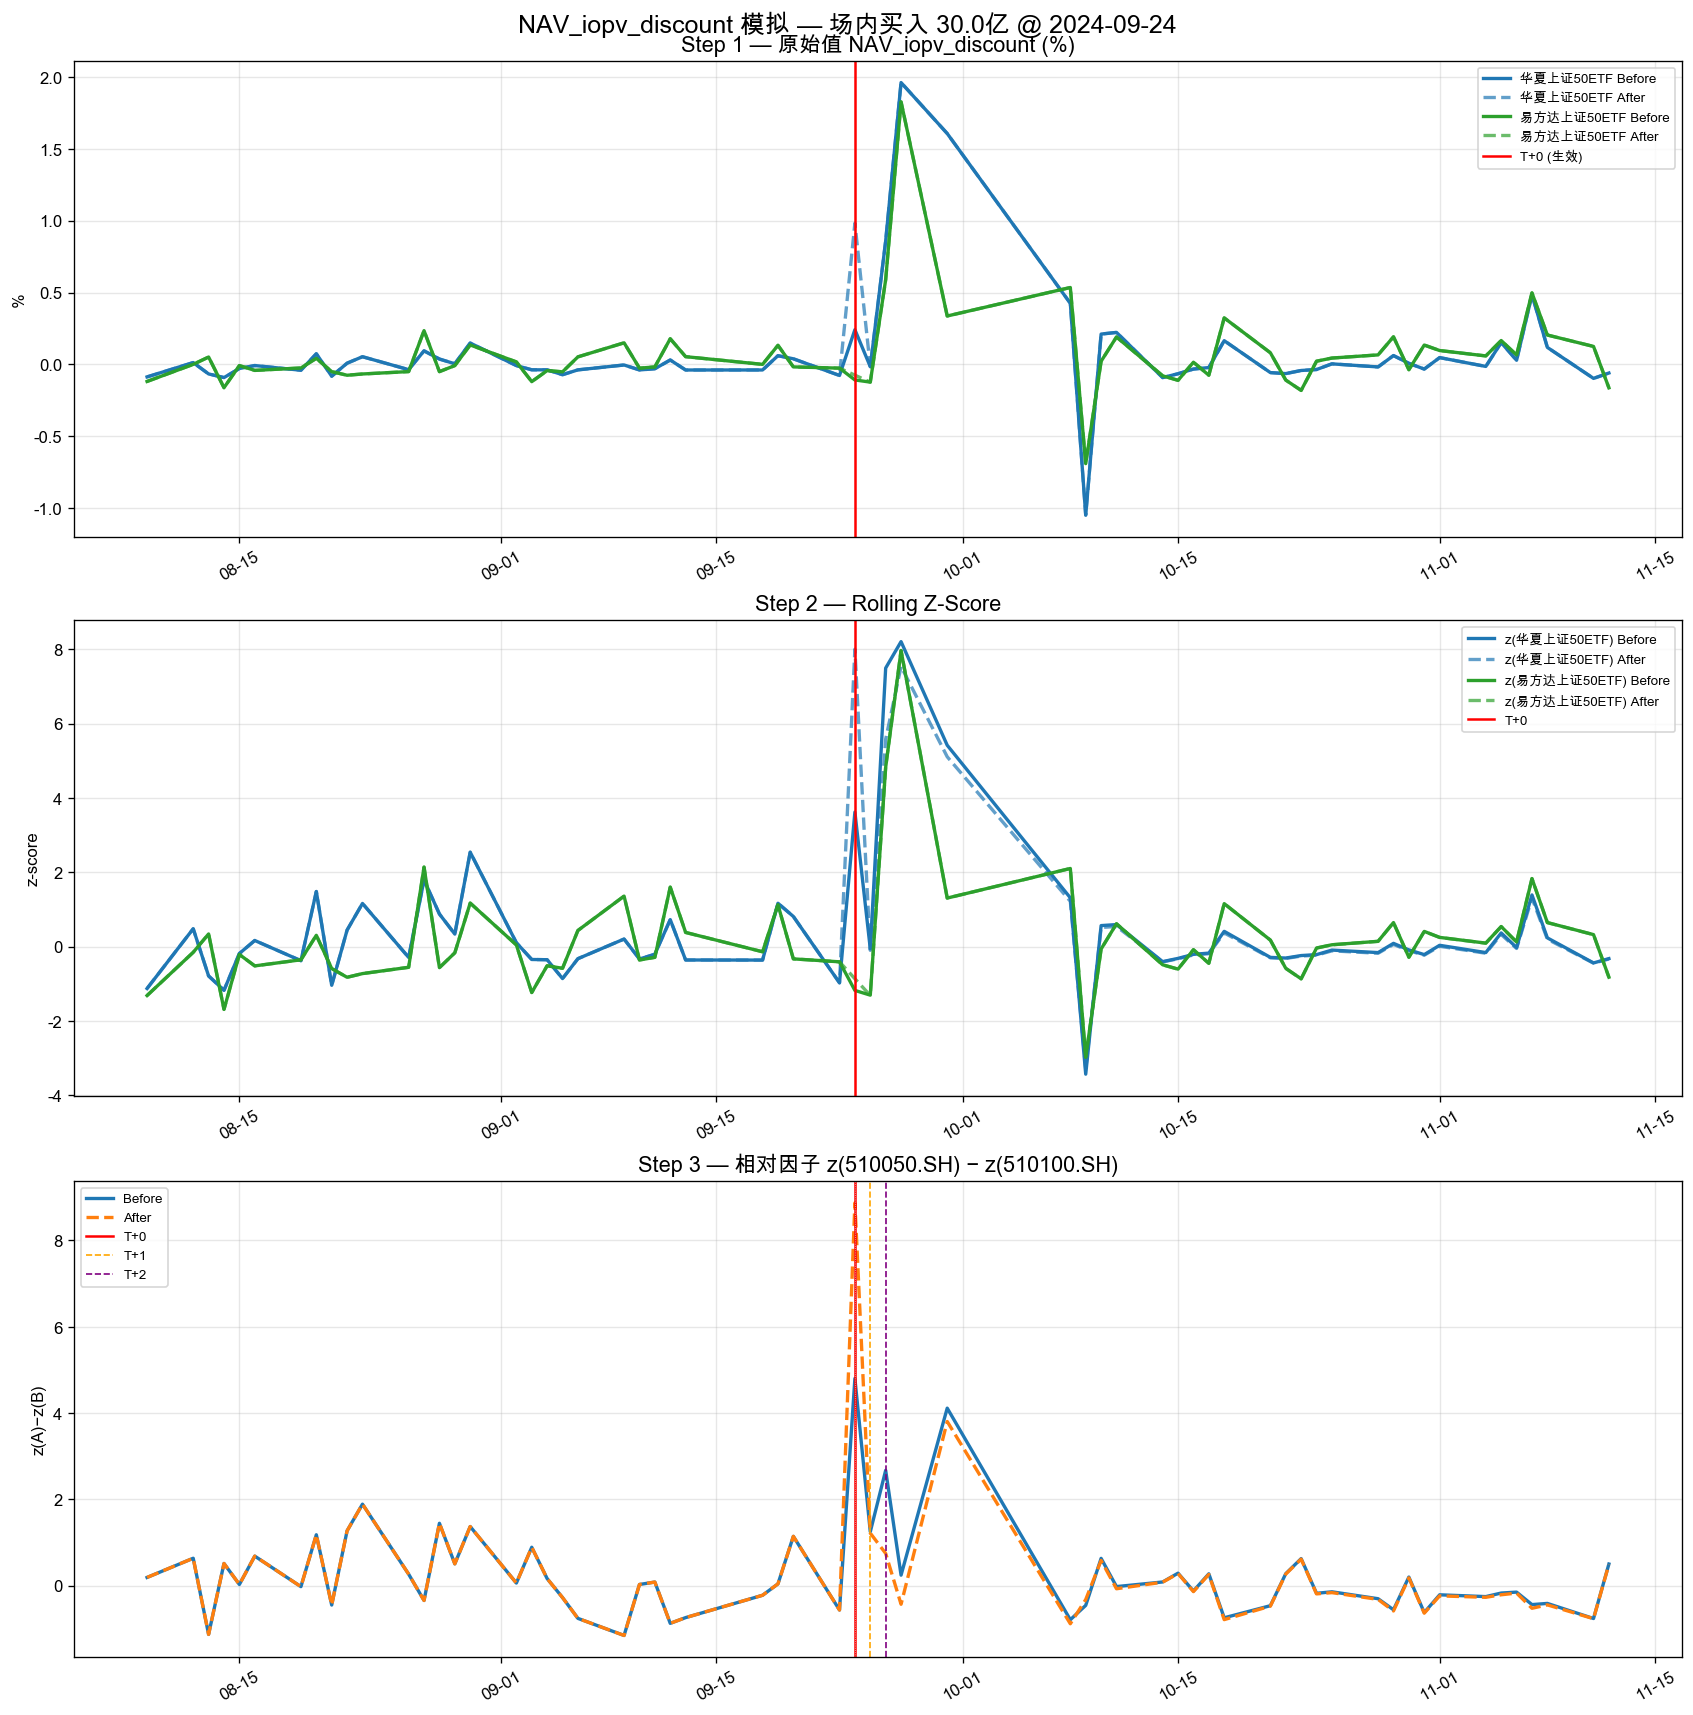

In [5]:
import pandas as pd
fig, axes = plt.subplots(3, 1, figsize=(14, 14), constrained_layout=True)

for code, label, c in [(CODE_A, NAME_A, '#1f77b4'), (CODE_B, NAME_B, '#2ca02c')]:
    axes[0].plot(dates, pd.to_numeric(df_orig.loc[mask, code], errors='coerce').tolist(), label=f'{label} Before', color=c, lw=2)
    axes[0].plot(dates, pd.to_numeric(df_mod.loc[mask, code], errors='coerce').tolist(), label=f'{label} After', color=c, lw=2, ls='--', alpha=0.7)
axes[0].axvline(sim_date, color='red', lw=1.5, label='T+0 (生效)')
axes[0].set_title(f'Step 1 — 原始值 NAV_iopv_discount ({UNIT})', fontsize=13)
axes[0].set_ylabel(UNIT); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')); axes[0].tick_params(axis='x', rotation=30)

for code, label, c in [(CODE_A, NAME_A, '#1f77b4'), (CODE_B, NAME_B, '#2ca02c')]:
    axes[1].plot(dates, z_before.loc[mask, code].tolist(), label=f'z({label}) Before', color=c, lw=2)
    axes[1].plot(dates, z_after.loc[mask, code].tolist(), label=f'z({label}) After', color=c, lw=2, ls='--', alpha=0.7)
axes[1].axvline(sim_date, color='red', lw=1.5, label='T+0')
axes[1].set_title('Step 2 — Rolling Z-Score', fontsize=13)
axes[1].set_ylabel('z-score'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')); axes[1].tick_params(axis='x', rotation=30)

plot_ba(axes[2], dates, rel_before[mask].tolist(), rel_after[mask].tolist(),
        f'Step 3 — 相对因子 z({CODE_A}) − z({CODE_B})', 'z(A)−z(B)', sim_date, t1, t2)

plt.suptitle(f'NAV_iopv_discount 模拟 — 场内买入 {BUY_ON_EXCHANGE}亿 @ {SIM_DATE}', fontsize=15, y=1.01)
plt.show()